# 06b - Radar espacial: usando as 434 células sem destruir a localização

**Notebook opcional de pesquisa.** O pipeline principal continua válido sem ele.

No notebook 06 resumimos cada mapa de radar com média, máximo, percentis e fração molhada. Isso é robusto, mas pode apagar a informação de **onde** a chuva está. Aqui testamos uma alternativa intermediária entre “resumir tudo” e treinar uma CNN/ConvLSTM: usamos as **434 células** e comprimimos seus padrões espaciais com `IncrementalPCA`, ajustado **somente no treino**.

O alvo continua sendo exclusivamente `ΔH_2h` da **estação 413**. Este notebook não abre 2025.

In [1]:
from pathlib import Path
import json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

warnings.filterwarnings("ignore")
CWD = Path.cwd().resolve()
ROOT = CWD.parent if CWD.name.lower() == "notebooks" else CWD
RAW_PARENT = ROOT / "data" / "raw"
PROCESSED = ROOT / "data" / "processed"
MODELS = ROOT / "models"
OUTPUTS = ROOT / "outputs"
TABLES = OUTPUTS / "tables"
FIGURES = OUTPUTS / "figures"
PREDICTIONS = OUTPUTS / "predictions"
for p in [PROCESSED, MODELS, TABLES, FIGURES, PREDICTIONS]: p.mkdir(parents=True, exist_ok=True)

def find_dataset_root(raw_parent: Path) -> Path:
    candidates = [raw_parent] + [p for p in raw_parent.rglob("*") if p.is_dir()]
    for p in candidates:
        data = p / "Data"
        if (data / "Radar").exists() and (data / "Telemetric_Time_Series").exists():
            return p
    raise FileNotFoundError("Dataset não encontrado dentro de data/raw/.")

RAW = find_dataset_root(RAW_PARENT)
RADAR_PRE = RAW / "Data" / "Radar" / "radar_20150401_to_20250329_0000.csv"
FEATURES = PROCESSED / "features_causal.parquet"
RADAR_AGG = PROCESSED / "radar_features_basic.parquet"
for p in [RADAR_PRE, FEATURES, RADAR_AGG]:
    if not p.exists(): raise FileNotFoundError(p)
print(RADAR_PRE)

C:\Users\osmar\Área de Trabalho\field-project\data\raw\TTI-HydroMet_Dataset_version2\Data\Radar\radar_20150401_to_20250329_0000.csv


## 1. Por que PCA?

O radar contém 434 valores por horário. Colocar milhares de células e lags diretamente no XGBoost aumenta muito memória e risco de overfitting. A PCA aprende combinações lineares dos mapas que explicam os principais padrões espaciais.

Crucialmente, o PCA é ajustado **somente em 2015–2022**. 2023/2024 não influenciam os componentes. Isso evita vazamento temporal.

PCA ainda não é uma solução espaço-temporal completa: ela não entende explicitamente rios/sub-bacias. É um **teste de ablação** para descobrir se a localização das 434 células contém sinal além dos agregados atuais.

In [2]:
from sklearn.decomposition import IncrementalPCA

N_COMPONENTS = 32
CHUNK_SIZE = 5000
TARGET = "target_delta_120m"

features = pd.read_parquet(FEATURES).sort_index()
header = pd.read_csv(RADAR_PRE, nrows=0).columns.tolist()
time_col, cell_cols = header[0], header[1:]
print("Células de radar:", len(cell_cols))
assert len(cell_cols) >= 400, "Esperava centenas de células no radar."

# Índices que podem participar do ajuste da PCA.
train_times = set(features.index[features["split"] == "train"])

ipca = IncrementalPCA(n_components=N_COMPONENTS, batch_size=CHUNK_SIZE)
fitted_rows = 0
for i, chunk in enumerate(pd.read_csv(RADAR_PRE, chunksize=CHUNK_SIZE)):
    chunk[time_col] = pd.to_datetime(chunk[time_col], format="mixed", errors="coerce")
    train_chunk = chunk[chunk[time_col].isin(train_times)]
    if len(train_chunk) < N_COMPONENTS:
        continue
    X = train_chunk[cell_cols].apply(pd.to_numeric, errors="coerce").fillna(0.0).to_numpy(dtype="float32")
    ipca.partial_fit(X)
    fitted_rows += len(X)
    if i % 20 == 0:
        print(f"PCA: bloco {i+1}, linhas treino acumuladas={fitted_rows:,}")

if fitted_rows == 0:
    raise RuntimeError("Nenhuma linha de treino do radar foi encontrada.")
print("Variância explicada pelos componentes:", float(ipca.explained_variance_ratio_.sum()))

Células de radar: 434
PCA: bloco 1, linhas treino acumuladas=4,856
PCA: bloco 21, linhas treino acumuladas=104,856
PCA: bloco 41, linhas treino acumuladas=204,856
PCA: bloco 61, linhas treino acumuladas=304,856
PCA: bloco 81, linhas treino acumuladas=404,856
Variância explicada pelos componentes: 0.9086119493290304


## 2. Transformando todos os mapas de desenvolvimento

Fazemos uma segunda passagem pelo CSV e guardamos somente os 32 componentes. Isso reduz aproximadamente `434 -> 32` canais, preservando muito mais estrutura espacial que média/max/p90.

In [3]:
parts=[]
valid_times = set(features.index[features["split"].isin(["train","validation","test_2024"])])
for i, chunk in enumerate(pd.read_csv(RADAR_PRE, chunksize=CHUNK_SIZE)):
    chunk[time_col] = pd.to_datetime(chunk[time_col], format="mixed", errors="coerce")
    chunk = chunk[chunk[time_col].isin(valid_times)]
    if chunk.empty: continue
    X = chunk[cell_cols].apply(pd.to_numeric, errors="coerce").fillna(0.0).to_numpy(dtype="float32")
    Z = ipca.transform(X).astype("float32")
    z = pd.DataFrame(Z, columns=[f"radar_spatial_pc_{j+1:02d}" for j in range(N_COMPONENTS)])
    z.index = pd.DatetimeIndex(chunk[time_col].to_numpy())
    parts.append(z)
    if i % 20 == 0: print("Transformando bloco", i+1)

radar_pca = pd.concat(parts).groupby(level=0).mean().sort_index()
radar_pca.to_parquet(PROCESSED / "radar_spatial_pca_v7.parquet")
print(radar_pca.shape)
display(radar_pca.head())

Transformando bloco 1
Transformando bloco 21
Transformando bloco 41
Transformando bloco 61
Transformando bloco 81
Transformando bloco 101
(512826, 32)


,radar_spatial_pc_01,radar_spatial_pc_02,radar_spatial_pc_03,radar_spatial_pc_04,radar_spatial_pc_05,radar_spatial_pc_06,radar_spatial_pc_07,radar_spatial_pc_08,radar_spatial_pc_09,radar_spatial_pc_10,...,radar_spatial_pc_23,radar_spatial_pc_24,radar_spatial_pc_25,radar_spatial_pc_26,radar_spatial_pc_27,radar_spatial_pc_28,radar_spatial_pc_29,radar_spatial_pc_30,radar_spatial_pc_31,radar_spatial_pc_32
2015-04-02 00:00:00,-0.555198,-0.015196,-0.007173,-0.044955,-0.01321,-0.026847,-0.005468,0.002806,-0.01102,-0.013896,...,-0.003754,0.000541,-0.000798,-0.001613,0.000619,0.000758,-0.00323,0.002255,0.002298,-0.001333
2015-04-02 00:10:00,-0.555198,-0.015196,-0.007173,-0.044955,-0.01321,-0.026847,-0.005468,0.002806,-0.01102,-0.013896,...,-0.003754,0.000541,-0.000798,-0.001613,0.000619,0.000758,-0.00323,0.002255,0.002298,-0.001333
2015-04-02 00:20:00,-0.555198,-0.015196,-0.007173,-0.044955,-0.01321,-0.026847,-0.005468,0.002806,-0.01102,-0.013896,...,-0.003754,0.000541,-0.000798,-0.001613,0.000619,0.000758,-0.00323,0.002255,0.002298,-0.001333
2015-04-02 00:30:00,-0.555198,-0.015196,-0.007173,-0.044955,-0.01321,-0.026847,-0.005468,0.002806,-0.01102,-0.013896,...,-0.003754,0.000541,-0.000798,-0.001613,0.000619,0.000758,-0.00323,0.002255,0.002298,-0.001333
2015-04-02 00:40:00,-0.555198,-0.015196,-0.007173,-0.044955,-0.01321,-0.026847,-0.005468,0.002806,-0.01102,-0.013896,...,-0.003754,0.000541,-0.000798,-0.001613,0.000619,0.000758,-0.00323,0.002255,0.002298,-0.001333


## 3. Comparação justa: agregados atuais vs agregados + PCA espacial

Não substituímos as 166 features nem o radar agregado. Perguntamos apenas se adicionar os componentes espaciais melhora 2024. O número de árvores é escolhido em 2023 por early stopping, nunca em 2024.

In [4]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error

radar_agg = pd.read_parquet(RADAR_AGG).sort_index()
if radar_agg.index.has_duplicates:
    radar_agg = radar_agg.groupby(level=0).mean(numeric_only=True).sort_index()

df = features.join(radar_agg, how="left").join(radar_pca, how="left")
base_cols = [c for c in features.columns if c != "split" and not c.startswith("target_")]
agg_cols = list(radar_agg.columns)
pca_cols = list(radar_pca.columns)

def split_xy(name, cols):
    z = df[df["split"] == name].dropna(subset=[TARGET])
    return z, z[cols], z[TARGET]

def fit_model(cols):
    tr, Xtr, ytr = split_xy("train", cols)
    va, Xva, yva = split_xy("validation", cols)
    model = XGBRegressor(
        objective="reg:squarederror", eval_metric="rmse", tree_method="hist",
        n_estimators=1200, learning_rate=.035, max_depth=6, min_child_weight=20,
        subsample=.85, colsample_bytree=.80, reg_lambda=5, max_bin=128,
        n_jobs=-1, random_state=42, early_stopping_rounds=60,
    )
    model.fit(Xtr, ytr, eval_set=[(Xva,yva)], verbose=False)
    return model

experiments = {
    "agregado": base_cols + agg_cols,
    "agregado_mais_pca_espacial": base_cols + agg_cols + pca_cols,
}
rows=[]; preds={}
for name, cols in experiments.items():
    print("Treinando", name, "com", len(cols), "features")
    model = fit_model(cols)
    te, Xte, yte = split_xy("test_2024", cols)
    pred = model.predict(Xte)
    preds[name] = (te.index, yte.to_numpy(), pred)
    err = pred-yte.to_numpy()
    rows.append({
        "model": name, "n_features": len(cols),
        "MAE_cm": 100*np.mean(np.abs(err)),
        "RMSE_cm": 100*np.sqrt(np.mean(err**2)),
        "MAE_gt3m_cm": 100*np.mean(np.abs(err[yte.to_numpy()>=3])) if np.any(yte.to_numpy()>=3) else np.nan,
        "best_iteration": getattr(model, "best_iteration", np.nan),
    })
    model.save_model(MODELS / f"xgb_radar_{name}_dev_v7.json")

comparison = pd.DataFrame(rows)
comparison.to_csv(TABLES / "radar_spatial_pca_comparison_2024_v7.csv", index=False)
display(comparison)

Treinando agregado com 210 features
Treinando agregado_mais_pca_espacial com 242 features


,model,n_features,MAE_cm,RMSE_cm,MAE_gt3m_cm,best_iteration
0,agregado,210,6.093930,20.299667,226.841568,504
1,agregado_mais_pca_espacial,242,6.032254,20.241432,232.187057,322


## 4. Como decidir

- Se PCA espacial melhora apenas décimos de centímetro no RMSE e não melhora `>3 m`, provavelmente não vale a complexidade.
- Se melhora principalmente os extremos, é evidência de que **onde a tempestade está** importa e justifica uma etapa futura com CNN/ConvLSTM ou agregação por sub-bacia.
- Este notebook **não altera automaticamente o notebook 08**. Primeiro compare os resultados no desenvolvimento.

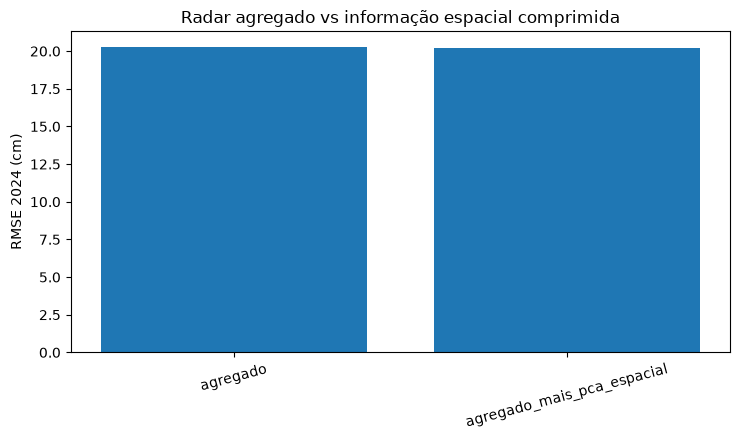

In [5]:
fig, ax = plt.subplots(figsize=(7.5,4.5))
ax.bar(comparison["model"], comparison["RMSE_cm"])
ax.set_ylabel("RMSE 2024 (cm)")
ax.set_title("Radar agregado vs informação espacial comprimida")
ax.tick_params(axis="x", rotation=15)
fig.tight_layout()
fig.savefig(FIGURES / "v7_radar_spatial_pca_rmse.png", dpi=170, bbox_inches="tight")
plt.show()